In [1]:
# how to uncover truths that don't matter - third section
# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

In [2]:
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans, DBSCAN

import coriolis_functions

In [3]:
fdf = pd.read_csv("data/coriolis_flights_3m.csv", sep=";").astype(
    {
        "FL_DATE": "datetime64[ns]", 
        "AIRLINE": "category", 
        "AIRLINE_DOT": "category", 
        "AIRLINE_CODE": "category", 
        "ORIGIN": "category", 
        "ORIGIN_CITY": "category", 
        "DEST": "category",
        "DEST_CITY": "category", 
        "CANCELLED": "bool",
        "CANCELLATION_CODE": "category", 
        "DIVERTED": "bool",
    }
)

In [4]:
ldf = pd.read_csv("data/airports.csv").astype(
    {
        "IATA": "category",
        "AIRPORT": "category",
        "CITY": "category",
        "STATE": "category",
        "COUNTRY": "category",
    }
)

In [5]:
# checking unique values in both datasets
fdf_airports = set(fdf["ORIGIN"].unique()).union(set(fdf["DEST"].unique()))
ldf_airports = set(ldf["IATA"].unique())  

# finding missing airport codes in ldf
missing_airports = fdf_airports.difference(ldf_airports)

# dropping rows where "ORIGIN" or "DEST" are in missing_airports
fdf = fdf[~fdf["ORIGIN"].isin(missing_airports) & ~fdf["DEST"].isin(missing_airports)]

# merging fdf with ldf to add geographical data for ORIGIN and DEST
fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="ORIGIN", right_on="IATA", how="left")

fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="DEST", right_on="IATA", how="left", suffixes=("_ORIGIN", "_DEST"))

# dropping original origin and destination columns
fdf = fdf.drop(["ORIGIN", "DEST"], axis=1)

# enforcing categories on newly generated columns
fdf[["IATA_ORIGIN", "IATA_DEST"]] = fdf[["IATA_ORIGIN", "IATA_DEST"]].astype("category")

In [6]:
print(fdf.columns)

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN_CITY', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME',
       'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN',
       'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED',
       'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME',
       'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
       'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
       'total_drift_distance', 'IATA_ORIGIN', 'LATITUDE_ORIGIN',
       'LONGITUDE_ORIGIN', 'IATA_DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST'],
      dtype='object')


In [7]:
fdf = fdf.drop([
    'FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
   'FL_NUMBER', 'CRS_DEP_TIME', 'DEP_TIME',
   'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN',
   'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED',
   'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME',
   'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
   'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
], axis=1)

In [8]:
# calculating haversinedistance
fdf["haversine_distance"] = coriolis_functions.haversine(
    fdf["LATITUDE_ORIGIN"],
    fdf["LONGITUDE_ORIGIN"],
    fdf["LATITUDE_DEST"], 
    fdf["LONGITUDE_DEST"]
)

In [9]:
# printing number of before rows 
print("number of rows before cleaning: ", rows_before_cleaning := len(fdf))

# clean up for model
fdf.dropna(subset=["total_drift_distance", "haversine_distance"], inplace=True)

# printing number of rows after cleaning
print("number of rows after cleaning: ", len(fdf))
print("number of rows lost due cleaning: ", rows_before_cleaning - len(fdf))

number of rows before cleaning:  2948087
number of rows after cleaning:  2730145
number of rows lost due cleaning:  217942


In [10]:
# extracting data into 2D numpy array
data = fdf[["haversine_distance", "total_drift_distance"]].to_numpy()

In [11]:
# defining a function for DBSCAN and plotting
def db_scanner(data, fdf, epsilon, minimum_samples):
    # configuring DBSCAN parameters
    dbscan = DBSCAN(eps=epsilon, min_samples=minimum_samples)
    clusters = dbscan.fit_predict(data)
    
    # adding cluster labels to the dataframe
    fdf["cluster"] = clusters
    
    # creating a figure with 2 subplots, one above the other
    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    
    # first plot: including noise
    sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf, hue="cluster", palette="viridis", alpha=0.5, ax=axes[0])
    axes[0].set_title("DBSCAN Clustering (Including Noise)")
    axes[0].set_xlabel("Haversine Distance")
    axes[0].set_ylabel("Total Drift Distance")
    axes[0].legend(loc="upper left", title="Cluster")
    
    # second plot: excluding noise
    sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf[fdf["cluster"] != -1], hue="cluster", palette="viridis", alpha=0.5, ax=axes[1])
    axes[1].set_title("DBSCAN Clustering (Excluding Noise)")
    axes[1].set_xlabel("Haversine Distance")
    axes[1].set_ylabel("Total Drift Distance")
    axes[1].legend(loc="upper left", title="Cluster")
    
    # adjust layout
    plt.tight_layout()
    plt.show()
    
    # Print information about noise
    print(f"Flights not considered 'noise': {len(fdf[fdf['cluster'] != -1])}")
    print(f"Flights considered 'noise': {len(fdf[fdf['cluster'] == -1])}")


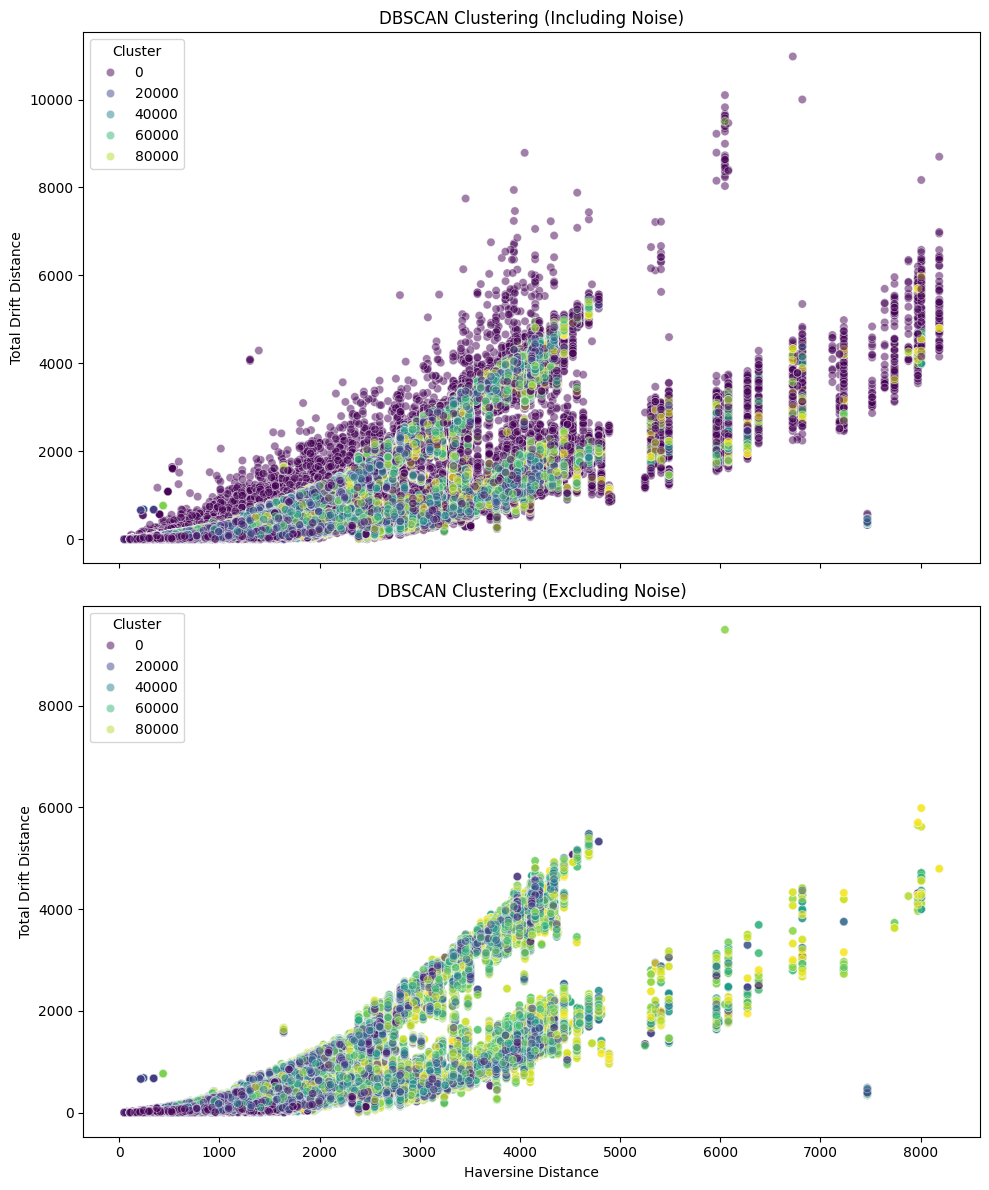

Flights not considered 'noise': 2643046
Flights considered 'noise': 87099


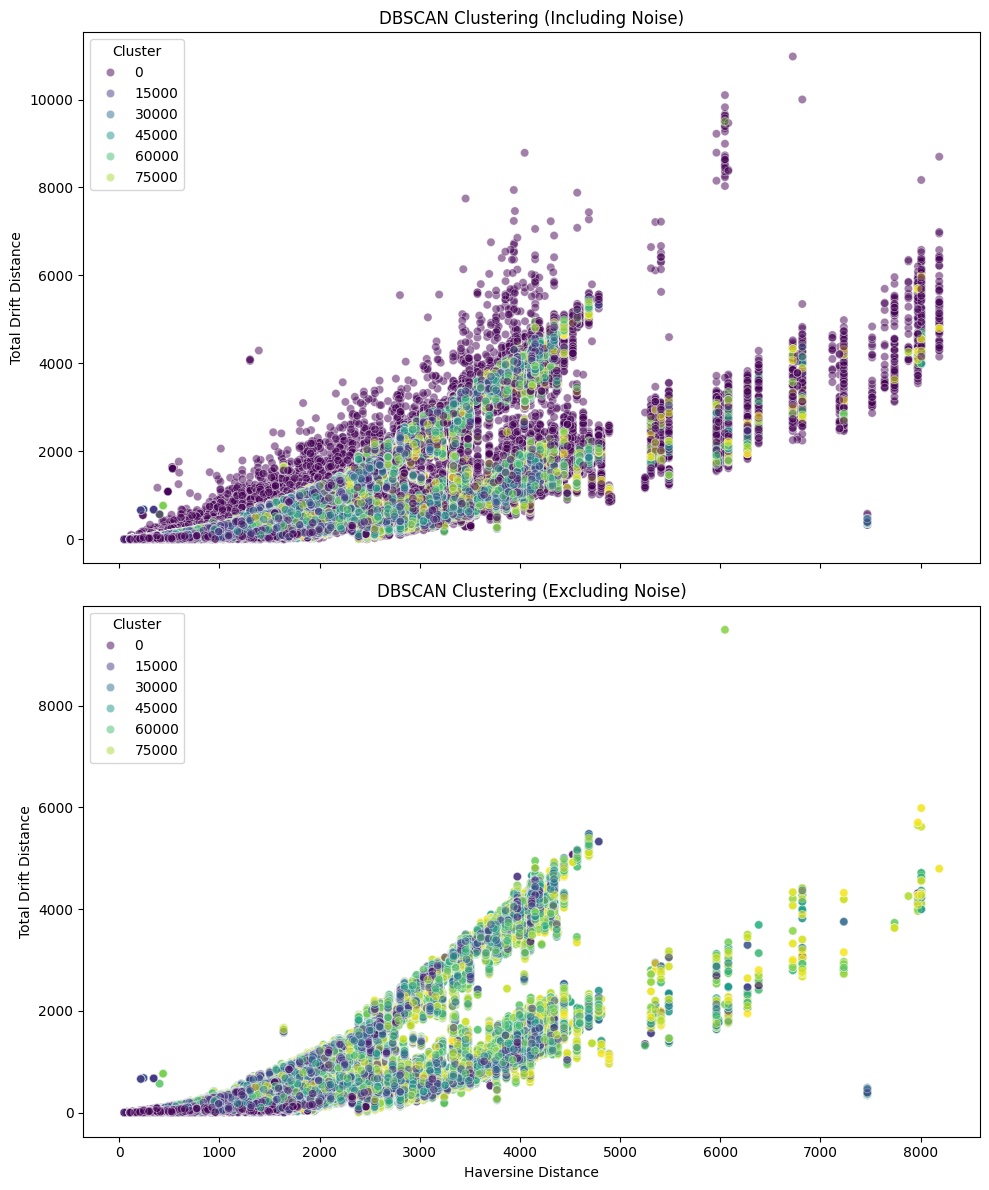

Flights not considered 'noise': 2646811
Flights considered 'noise': 83334


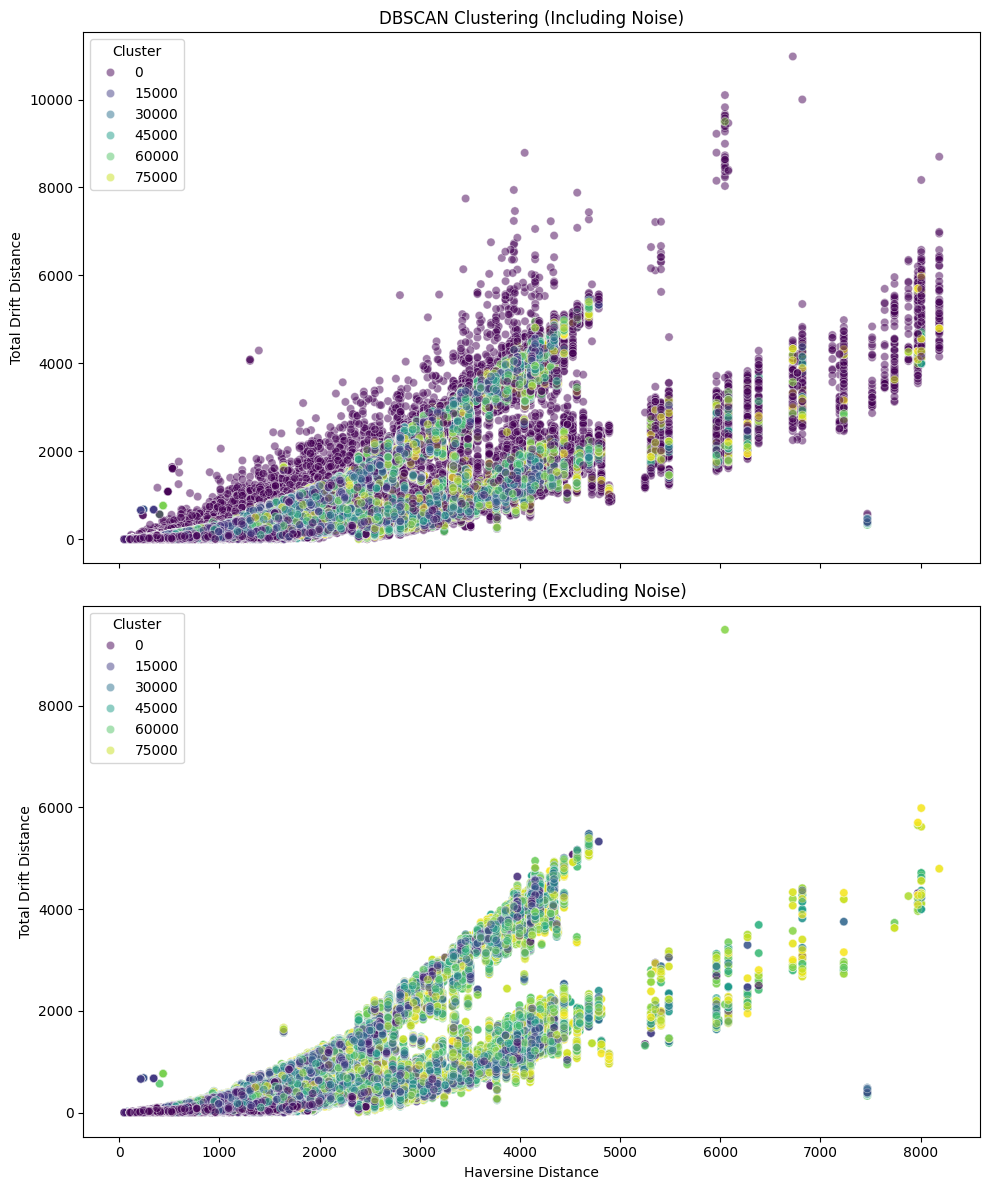

Flights not considered 'noise': 2650364
Flights considered 'noise': 79781


In [12]:
start = 7
end = 10

epsilons = [x * 0.1 for x in range(start, end)]
min_samples = [3 for _ in range(start, end)]

for epsilon, min_sample in zip(epsilons, min_samples):
    db_scanner(data, fdf, epsilon, min_sample)